# Algorithms 

In [14]:
# Used to store values needed during visualizations

all_predictions = {}
all_metrics = []
all_trading = []

In [16]:
# computes sharpe ratio 
import numpy as np

def compute_sharpe_ratio(daily_returns, annualize=True, periods_per_year=252):
    daily_returns = np.asarray(daily_returns, dtype=float)
    daily_returns = daily_returns[~np.isnan(daily_returns)]

    if len(daily_returns) < 2:
        return np.nan

    std_ret = np.std(daily_returns, ddof=1)
    if std_ret == 0:
        return np.nan

    sharpe = np.mean(daily_returns) / std_ret

    if annualize:
        sharpe *= np.sqrt(periods_per_year)

    return sharpe

## Layer One: Traditional Models
### Models: Logistic Regression & MLP Classifier

### Logistic Regression 

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

model_name = "logreg"

#The stocks we are analyzing
tickers = ["CMG", "BB", "M", "QQQ"]
prices = {}

for ticker_symbol in tickers:
    ticker = yf.Ticker(ticker_symbol)
    prices[ticker_symbol] = ticker.history(start="2009-02-14", end="2020-06-11")
    print(f"\n{ticker_symbol}:")
    print(prices[ticker_symbol])

# Collect features: use yesterday's information to predict today's outcome
for ticker_symbol in tickers:
    price = prices[ticker_symbol]

    #Calculate all the needed metrics
    price["Change"]      = price["Close"].shift(1) - price["Open"].shift(1)
    price["Score"]       = (price["Close"] > price["Open"]).astype(int)
    price["%Change"]     = (price["Close"].shift(1) - price["Open"].shift(1)) / price["Open"].shift(1)
    price["CloseToOpen"] = price["Open"].shift(1) - price["Close"].shift(1)
    price["YestScore"]   = price["Score"].shift(1)
    price["5DayMean"]    = price["Close"].rolling(5).mean().shift(1)
    price["5DayVoli"]    = price["Close"].rolling(5).std().shift(1)
    price["5DayPerf"]    = price["Score"].rolling(5).sum().shift(1)

    price.dropna(inplace=True)
    prices[ticker_symbol] = price
    print(f"\n{ticker_symbol}:")
    print(price["5DayPerf"])


features = ["Change", "%Change", "CloseToOpen", "YestScore", "5DayMean", "5DayVoli", "5DayPerf"]
model_results = {}

for ticker_symbol in tickers:
    #Grab the train/test data and split it up
    price = prices[ticker_symbol]
    priceTrain = price[price.index <= "2018-06-11"].copy()
    priceTest = price[price.index > "2018-06-11"].copy()

    results = []

    #Run through each day, adjusting the training set every day
    for i in range(len(priceTest)):
        xTrain = priceTrain[features]
        yTrain = priceTrain["Score"]

        #Proerly fit the data
        scaler = StandardScaler()
        xTrain_scaled = scaler.fit_transform(xTrain)

        #Train the model
        model = LogisticRegression()
        model.fit(xTrain_scaled, yTrain)

        # Predict today's outcome using today's row, whose features already contain yesterday's shifted information
        current_row = priceTest.iloc[[i]]
        current_row_scaled = scaler.transform(current_row[features])

        results.append({"Date": priceTest.index[i],
                        "Score": priceTest["Score"].iloc[i],
                        "Prediction": pred,
                        "Probability": prob,
                        "Open": priceTest["Open"].iloc[i],
                        "Close": priceTest["Close"].iloc[i]})

        results.append({
            "Date": priceTest.index[i],
            "Score": priceTest["Score"].iloc[i],
            "Prediction": pred,
            "Probability": prob,
            "Open": priceTest["Open"].iloc[i],
            "Close": priceTest["Close"].iloc[i]
        })

        # Expand training set walk-forward style
        priceTrain = pd.concat([priceTrain, current_row])

for ticker_symbol, results in all_results.items():
    score = results["Score"]
    pred = results["Prediction"]

    accuracy  = accuracy_score(score, pred)
    precision = precision_score(score, pred, zero_division=0)
    recall    = recall_score(score, pred, zero_division=0)
    f1        = f1_score(score, pred, zero_division=0)
    mcc       = matthews_corrcoef(score, pred)

    all_metrics.append({
        "model": model_name,
        "ticker": ticker_symbol,
        "mean": results["Score"].mean(),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mcc": mcc
    })

    print(f"\n{ticker_symbol}:")
    print("Mean:     ", results["Score"].mean())
    print("Accuracy: ", accuracy)
    print("Precision:", precision)
    print("Recall:   ", recall)
    print("F1:       ", f1)
    print("MCC:      ", mcc)

# Trading evaluation
for ticker_symbol, results in model_results.items():
    score = results["Score"]
    pred = results["Prediction"]
    op = results["Open"]
    close = results["Close"]

    totalIn = totalOut = totalInvested = totalStoodOut = 0
    alltradein = alltradeout = 0
    perftradein = perftradeout = 0

    model_daily_returns = []
    buyhold_daily_returns = []
    perfect_daily_returns = []

    for i, o, c, s in zip(pred.values, op.values, close.values, score.values):
        ret_decimal = (c - o) / o
        ret_percent = ret_decimal * 100

        if i == 1:
            totalIn += 100
            totalInvested += 1
            totalOut += 100 + ret_percent
            model_daily_returns.append(ret_decimal)
        else:
            totalStoodOut += 1
            model_daily_returns.append(0.0)

        alltradein += 100
        alltradeout += 100 + ret_percent
        buyhold_daily_returns.append(ret_decimal)

        if s == 1:
            perftradein += 100
            perftradeout += 100 + ret_percent
            perfect_daily_returns.append(ret_decimal)
        else:
            perfect_daily_returns.append(0.0)

    model_profit = totalOut - totalIn
    buyhold_profit = alltradeout - alltradein
    perfect_profit = perftradeout - perftradein

    model_sharpe = compute_sharpe_ratio(model_daily_returns)
    buyhold_sharpe = compute_sharpe_ratio(buyhold_daily_returns)
    perfect_sharpe = compute_sharpe_ratio(perfect_daily_returns)

    all_trading.append({
        "model": model_name,
        "ticker": ticker_symbol,
        "profit_model": model_profit,
        "profit_buyhold": buyhold_profit,
        "profit_perfect": perfect_profit,
        "sharpe_model": model_sharpe,
        "sharpe_buyhold": buyhold_sharpe,
        "sharpe_perfect": perfect_sharpe,
        "trades": totalInvested,
        "skipped": totalStoodOut
    })

    print(f"\n{ticker_symbol}:")
    print(f"  Model:    Invested ${totalIn:.0f}, Returned ${totalOut:.2f}, Profit ${model_profit:.2f} ({totalInvested} trades, {totalStoodOut} skipped), Sharpe {model_sharpe:.3f}")
    print(f"  Buy&Hold: Invested ${alltradein:.0f}, Returned ${alltradeout:.2f}, Profit ${buyhold_profit:.2f}, Sharpe {buyhold_sharpe:.3f}")
    print(f"  Perfect:  Invested ${perftradein:.0f}, Returned ${perftradeout:.2f}, Profit ${perfect_profit:.2f}, Sharpe {perfect_sharpe:.3f}")


CMG:
                                Open       High        Low      Close  \
Date                                                                    
2009-02-17 00:00:00-05:00   1.097600   1.098800   1.057000   1.067200   
2009-02-18 00:00:00-05:00   1.069800   1.093000   1.048600   1.089000   
2009-02-19 00:00:00-05:00   1.106200   1.120000   1.068800   1.074800   
2009-02-20 00:00:00-05:00   1.054000   1.118000   1.048200   1.110000   
2009-02-23 00:00:00-05:00   1.121400   1.134200   1.086000   1.093400   
...                              ...        ...        ...        ...   
2020-06-04 00:00:00-04:00  20.886200  21.196199  20.700001  20.831200   
2020-06-05 00:00:00-04:00  21.000000  21.382000  20.901800  21.069201   
2020-06-08 00:00:00-04:00  21.056601  21.299999  20.664400  20.984600   
2020-06-09 00:00:00-04:00  20.738199  21.059799  20.700001  20.789400   
2020-06-10 00:00:00-04:00  20.852400  20.858801  20.469801  20.579201   

                             Volume  Dividen

#### Comments and Analysis for Logistic Regression

TODO

### MLP Classifier 

In [18]:
import yfinance as yf
import pandas as pd
import numpy as np

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

model_name = "single_day_mlp"

tickers = ["CMG", "BB", "M", "QQQ"]
prices = {}

for ticker_symbol in tickers:
    ticker = yf.Ticker(ticker_symbol)
    prices[ticker_symbol] = ticker.history(start="2009-02-14", end="2020-06-11")
    print(f"\n{ticker_symbol}:")
    print(prices[ticker_symbol])

# Collect features: use yesterday's information to predict today's outcome
for ticker_symbol in tickers:
    price = prices[ticker_symbol]

    price["Change"]      = price["Close"].shift(1) - price["Open"].shift(1)
    price["Score"]       = (price["Close"] > price["Open"]).astype(int)
    price["%Change"]     = (price["Close"].shift(1) - price["Open"].shift(1)) / price["Open"].shift(1)
    price["CloseToOpen"] = price["Open"].shift(1) - price["Close"].shift(1)
    price["YestScore"]   = price["Score"].shift(1)
    price["5DayMean"]    = price["Close"].rolling(5).mean().shift(1)
    price["5DayVoli"]    = price["Close"].rolling(5).std().shift(1)
    price["5DayPerf"]    = price["Score"].rolling(5).sum().shift(1)

    price.dropna(inplace=True)
    prices[ticker_symbol] = price

features = ["Change", "%Change", "CloseToOpen", "YestScore", "5DayMean", "5DayVoli", "5DayPerf"]
model_results = {}

for ticker_symbol in tickers:
    price = prices[ticker_symbol]
    priceTrain = price[price.index <= "2018-06-11"].copy()
    priceTest = price[price.index > "2018-06-11"].copy()

    results = []

    for i in range(len(priceTest)):
        xTrain = priceTrain[features]
        yTrain = priceTrain["Score"]

        scaler = StandardScaler()
        xTrain_scaled = scaler.fit_transform(xTrain)

        model = MLPClassifier(hidden_layer_sizes=(32,), max_iter=1000, random_state=42)
        model.fit(xTrain_scaled, yTrain)

        # Predict today's outcome using today's row, whose features already contain yesterday's shifted information
        current_row = priceTest.iloc[[i]]
        current_row_scaled = scaler.transform(current_row[features])

        pred = model.predict(current_row_scaled)[0]
        prob = model.predict_proba(current_row_scaled)[0][1]

        results.append({
            "Date": priceTest.index[i],
            "Score": priceTest["Score"].iloc[i],
            "Prediction": pred,
            "Probability": prob,
            "Open": priceTest["Open"].iloc[i],
            "Close": priceTest["Close"].iloc[i]
        })

        # Expand training set walk-forward style
        priceTrain = pd.concat([priceTrain, current_row])

    model_results[ticker_symbol] = pd.DataFrame(results)

# Store full prediction outputs for later plotting/inspection
all_predictions[model_name] = model_results

# Classification metrics
for ticker_symbol, results in model_results.items():
    score = results["Score"]
    pred = results["Prediction"]

    accuracy  = accuracy_score(score, pred)
    precision = precision_score(score, pred, zero_division=0)
    recall    = recall_score(score, pred, zero_division=0)
    f1        = f1_score(score, pred, zero_division=0)
    mcc       = matthews_corrcoef(score, pred)

    all_metrics.append({
        "model": model_name,
        "ticker": ticker_symbol,
        "mean": results["Score"].mean(),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mcc": mcc
    })

    print(f"\n{ticker_symbol}:")
    print("Mean:     ", results["Score"].mean())
    print("Accuracy: ", accuracy)
    print("Precision:", precision)
    print("Recall:   ", recall)
    print("F1:       ", f1)
    print("MCC:      ", mcc)

# Trading evaluation
for ticker_symbol, results in model_results.items():
    score = results["Score"]
    pred = results["Prediction"]
    op = results["Open"]
    close = results["Close"]

    totalIn = totalOut = totalInvested = totalStoodOut = 0
    alltradein = alltradeout = 0
    perftradein = perftradeout = 0

    model_daily_returns = []
    buyhold_daily_returns = []
    perfect_daily_returns = []

    for i, o, c, s in zip(pred.values, op.values, close.values, score.values):
        ret_decimal = (c - o) / o
        ret_percent = ret_decimal * 100

        if i == 1:
            totalIn += 100
            totalInvested += 1
            totalOut += 100 + ret_percent
            model_daily_returns.append(ret_decimal)
        else:
            totalStoodOut += 1
            model_daily_returns.append(0.0)

        alltradein += 100
        alltradeout += 100 + ret_percent
        buyhold_daily_returns.append(ret_decimal)

        if s == 1:
            perftradein += 100
            perftradeout += 100 + ret_percent
            perfect_daily_returns.append(ret_decimal)
        else:
            perfect_daily_returns.append(0.0)

    model_profit = totalOut - totalIn
    buyhold_profit = alltradeout - alltradein
    perfect_profit = perftradeout - perftradein

    model_sharpe = compute_sharpe_ratio(model_daily_returns)
    buyhold_sharpe = compute_sharpe_ratio(buyhold_daily_returns)
    perfect_sharpe = compute_sharpe_ratio(perfect_daily_returns)

    all_trading.append({
        "model": model_name,
        "ticker": ticker_symbol,
        "profit_model": model_profit,
        "profit_buyhold": buyhold_profit,
        "profit_perfect": perfect_profit,
        "sharpe_model": model_sharpe,
        "sharpe_buyhold": buyhold_sharpe,
        "sharpe_perfect": perfect_sharpe,
        "trades": totalInvested,
        "skipped": totalStoodOut
    })

    print(f"\n{ticker_symbol}:")
    print(f"  Model:    Invested ${totalIn:.0f}, Returned ${totalOut:.2f}, Profit ${model_profit:.2f} ({totalInvested} trades, {totalStoodOut} skipped), Sharpe {model_sharpe:.3f}")
    print(f"  Buy&Hold: Invested ${alltradein:.0f}, Returned ${alltradeout:.2f}, Profit ${buyhold_profit:.2f}, Sharpe {buyhold_sharpe:.3f}")
    print(f"  Perfect:  Invested ${perftradein:.0f}, Returned ${perftradeout:.2f}, Profit ${perfect_profit:.2f}, Sharpe {perfect_sharpe:.3f}")


CMG:
                                Open       High        Low      Close  \
Date                                                                    
2009-02-17 00:00:00-05:00   1.097600   1.098800   1.057000   1.067200   
2009-02-18 00:00:00-05:00   1.069800   1.093000   1.048600   1.089000   
2009-02-19 00:00:00-05:00   1.106200   1.120000   1.068800   1.074800   
2009-02-20 00:00:00-05:00   1.054000   1.118000   1.048200   1.110000   
2009-02-23 00:00:00-05:00   1.121400   1.134200   1.086000   1.093400   
...                              ...        ...        ...        ...   
2020-06-04 00:00:00-04:00  20.886200  21.196199  20.700001  20.831200   
2020-06-05 00:00:00-04:00  21.000000  21.382000  20.901800  21.069201   
2020-06-08 00:00:00-04:00  21.056601  21.299999  20.664400  20.984600   
2020-06-09 00:00:00-04:00  20.738199  21.059799  20.700001  20.789400   
2020-06-10 00:00:00-04:00  20.852400  20.858801  20.469801  20.579201   

                             Volume  Dividen

#### Comments and Analysis for MLP Classifier 

TODO

## Layer Two: Time Series Models
### Models: Windowed MLP and LSTM  

### Windowed MLP

In [19]:
import yfinance as yf
import pandas as pd
import numpy as np

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

model_name = "windowed_mlp"

tickers = ["CMG", "BB", "M", "QQQ"]
prices = {}

for ticker_symbol in tickers:
    ticker = yf.Ticker(ticker_symbol)
    prices[ticker_symbol] = ticker.history(start="2009-02-14", end="2020-06-11")
    print(f"\n{ticker_symbol}:")
    print(prices[ticker_symbol])

# Collect features: use yesterday's information to predict today's outcome
for ticker_symbol in tickers:
    price = prices[ticker_symbol]

    price["Change"]      = price["Close"].shift(1) - price["Open"].shift(1)
    price["Score"]       = (price["Close"] > price["Open"]).astype(int)
    price["%Change"]     = (price["Close"].shift(1) - price["Open"].shift(1)) / price["Open"].shift(1)
    price["CloseToOpen"] = price["Open"].shift(1) - price["Close"].shift(1)
    price["YestScore"]   = price["Score"].shift(1)
    price["5DayMean"]    = price["Close"].rolling(5).mean().shift(1)
    price["5DayVoli"]    = price["Close"].rolling(5).std().shift(1)
    price["5DayPerf"]    = price["Score"].rolling(5).sum().shift(1)

    price.dropna(inplace=True)
    prices[ticker_symbol] = price

features = ["Change", "%Change", "CloseToOpen", "YestScore", "5DayMean", "5DayVoli", "5DayPerf"]
model_results = {}

for ticker_symbol in tickers:
    price = prices[ticker_symbol]

    # 5-year rolling training window
    priceTrain = price[(price.index <= "2018-06-11") & (price.index >= "2013-06-11")].copy()
    priceTest = price[price.index > "2018-06-11"].copy()

    results = []

    for i in range(len(priceTest)):
        xTrain = priceTrain[features]
        yTrain = priceTrain["Score"]

        scaler = StandardScaler()
        xTrain_scaled = scaler.fit_transform(xTrain)

        model = MLPClassifier(hidden_layer_sizes=(32,), max_iter=1000, random_state=42)
        model.fit(xTrain_scaled, yTrain)

        # Predict today's outcome using today's row, whose features already contain yesterday's shifted information
        current_row = priceTest.iloc[[i]]
        current_row_scaled = scaler.transform(current_row[features])

        pred = model.predict(current_row_scaled)[0]
        prob = model.predict_proba(current_row_scaled)[0][1]

        results.append({
            "Date": priceTest.index[i],
            "Score": priceTest["Score"].iloc[i],
            "Prediction": pred,
            "Probability": prob,
            "Open": priceTest["Open"].iloc[i],
            "Close": priceTest["Close"].iloc[i]
        })

        # Add the predicted day and drop the oldest row to keep the window size fixed
        priceTrain = pd.concat([priceTrain, current_row])
        priceTrain = priceTrain.iloc[1:]

    model_results[ticker_symbol] = pd.DataFrame(results)

# Store full prediction outputs for later plotting/inspection
all_predictions[model_name] = model_results

# Classification metrics
for ticker_symbol, results in model_results.items():
    score = results["Score"]
    pred = results["Prediction"]

    accuracy  = accuracy_score(score, pred)
    precision = precision_score(score, pred, zero_division=0)
    recall    = recall_score(score, pred, zero_division=0)
    f1        = f1_score(score, pred, zero_division=0)
    mcc       = matthews_corrcoef(score, pred)

    all_metrics.append({
        "model": model_name,
        "ticker": ticker_symbol,
        "mean": results["Score"].mean(),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mcc": mcc
    })

    print(f"\n{ticker_symbol}:")
    print("Mean:     ", results["Score"].mean())
    print("Accuracy: ", accuracy)
    print("Precision:", precision)
    print("Recall:   ", recall)
    print("F1:       ", f1)
    print("MCC:      ", mcc)

# Trading evaluation
for ticker_symbol, results in model_results.items():
    score = results["Score"]
    pred = results["Prediction"]
    op = results["Open"]
    close = results["Close"]

    totalIn = totalOut = totalInvested = totalStoodOut = 0
    alltradein = alltradeout = 0
    perftradein = perftradeout = 0

    model_daily_returns = []
    buyhold_daily_returns = []
    perfect_daily_returns = []

    for i, o, c, s in zip(pred.values, op.values, close.values, score.values):
        ret_decimal = (c - o) / o
        ret_percent = ret_decimal * 100

        if i == 1:
            totalIn += 100
            totalInvested += 1
            totalOut += 100 + ret_percent
            model_daily_returns.append(ret_decimal)
        else:
            totalStoodOut += 1
            model_daily_returns.append(0.0)

        alltradein += 100
        alltradeout += 100 + ret_percent
        buyhold_daily_returns.append(ret_decimal)

        if s == 1:
            perftradein += 100
            perftradeout += 100 + ret_percent
            perfect_daily_returns.append(ret_decimal)
        else:
            perfect_daily_returns.append(0.0)

    model_profit = totalOut - totalIn
    buyhold_profit = alltradeout - alltradein
    perfect_profit = perftradeout - perftradein

    model_sharpe = compute_sharpe_ratio(model_daily_returns)
    buyhold_sharpe = compute_sharpe_ratio(buyhold_daily_returns)
    perfect_sharpe = compute_sharpe_ratio(perfect_daily_returns)

    all_trading.append({
        "model": model_name,
        "ticker": ticker_symbol,
        "profit_model": model_profit,
        "profit_buyhold": buyhold_profit,
        "profit_perfect": perfect_profit,
        "sharpe_model": model_sharpe,
        "sharpe_buyhold": buyhold_sharpe,
        "sharpe_perfect": perfect_sharpe,
        "trades": totalInvested,
        "skipped": totalStoodOut
    })

    print(f"\n{ticker_symbol}:")
    print(f"  Model:    Invested ${totalIn:.0f}, Returned ${totalOut:.2f}, Profit ${model_profit:.2f} ({totalInvested} trades, {totalStoodOut} skipped), Sharpe {model_sharpe:.3f}")
    print(f"  Buy&Hold: Invested ${alltradein:.0f}, Returned ${alltradeout:.2f}, Profit ${buyhold_profit:.2f}, Sharpe {buyhold_sharpe:.3f}")
    print(f"  Perfect:  Invested ${perftradein:.0f}, Returned ${perftradeout:.2f}, Profit ${perfect_profit:.2f}, Sharpe {perfect_sharpe:.3f}")


CMG:
                                Open       High        Low      Close  \
Date                                                                    
2009-02-17 00:00:00-05:00   1.097600   1.098800   1.057000   1.067200   
2009-02-18 00:00:00-05:00   1.069800   1.093000   1.048600   1.089000   
2009-02-19 00:00:00-05:00   1.106200   1.120000   1.068800   1.074800   
2009-02-20 00:00:00-05:00   1.054000   1.118000   1.048200   1.110000   
2009-02-23 00:00:00-05:00   1.121400   1.134200   1.086000   1.093400   
...                              ...        ...        ...        ...   
2020-06-04 00:00:00-04:00  20.886200  21.196199  20.700001  20.831200   
2020-06-05 00:00:00-04:00  21.000000  21.382000  20.901800  21.069201   
2020-06-08 00:00:00-04:00  21.056601  21.299999  20.664400  20.984600   
2020-06-09 00:00:00-04:00  20.738199  21.059799  20.700001  20.789400   
2020-06-10 00:00:00-04:00  20.852400  20.858801  20.469801  20.579201   

                             Volume  Dividen

#### Comments and Analysis for Windowed MLP

TODO

### Long Short-Term Memory (LSTM)

In [33]:
%pip -q install yfinance tensorflow

import yfinance as yf
import pandas as pd
import numpy as np
import random
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

model_name = "lstm"

tickers = ["QQQ", "BB", "M", "CMG"]
prices = {}

for ticker_symbol in tickers:
    ticker = yf.Ticker(ticker_symbol)
    prices[ticker_symbol] = ticker.history(start="2009-02-14", end="2020-06-11")
    print(f"\n{ticker_symbol}:")
    print(prices[ticker_symbol])

for ticker_symbol in tickers:
    price = prices[ticker_symbol]

    price["Score"] = (price["Close"].shift(-1) > price["Close"]).astype(int)

    price["Change"]      = price["Close"].shift(1) - price["Open"].shift(1)
    price["%Change"]     = (price["Close"].shift(1) - price["Open"].shift(1)) / price["Open"].shift(1)
    price["CloseToOpen"] = price["Open"].shift(1) - price["Close"].shift(1)
    price["YestScore"]   = price["Score"].shift(1)
    price["5DayMean"]    = price["Close"].rolling(5).mean().shift(1)
    price["5DayVoli"]    = price["Close"].rolling(5).std().shift(1)
    price["5DayPerf"]    = price["Score"].rolling(5).sum().shift(1)

    price.dropna(inplace=True)
    prices[ticker_symbol] = price

features = ["Change", "%Change", "CloseToOpen", "YestScore", "5DayMean", "5DayVoli", "5DayPerf"]
window_size = 5
model_results = {}

def make_windows(feature_data, target_data, dates, window_size):
    X = []
    y = []
    d = []

    for i in range(window_size, len(feature_data)):
        X.append(feature_data[i-window_size:i])
        y.append(target_data[i])
        d.append(dates[i])

    return np.array(X), np.array(y), np.array(d)

for ticker_symbol in tickers:
    price = prices[ticker_symbol]

    priceTrain = price[price.index <= "2018-06-11"].copy()
    priceTest  = price[price.index > "2018-06-11"].copy()

    scaler = StandardScaler()

    xTrain_raw = priceTrain[features]
    xTest_raw  = priceTest[features]

    xTrain_scaled = scaler.fit_transform(xTrain_raw)
    xTest_scaled  = scaler.transform(xTest_raw)

    yTrain = priceTrain["Score"].values
    yTest  = priceTest["Score"].values

    train_dates = priceTrain.index
    test_dates  = priceTest.index

    X_train, y_train, d_train = make_windows(xTrain_scaled, yTrain, train_dates, window_size)

    combined_X = np.vstack([xTrain_scaled[-window_size:], xTest_scaled])
    combined_y = np.concatenate([yTrain[-window_size:], yTest])
    combined_d = np.concatenate([train_dates[-window_size:], test_dates])

    X_test, y_test, d_test = make_windows(combined_X, combined_y, combined_d, window_size)

    model = Sequential([
        LSTM(32, input_shape=(window_size, len(features))),
        Dropout(0.2),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=20,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    probs = model.predict(X_test, verbose=0).flatten()
    preds = (probs >= 0.5).astype(int)

    results = pd.DataFrame({
        "Date": d_test,
        "Score": y_test,
        "Prediction": preds,
        "Probability": probs
    })

    results["Open"] = price.loc[results["Date"], "Open"].values
    results["Close"] = price.loc[results["Date"], "Close"].values

    model_results[ticker_symbol] = results

    print(f"\nFinished {ticker_symbol}")
    print(results.head())

# Store full prediction outputs
all_predictions[model_name] = model_results

# Classification metrics
for ticker_symbol, results in model_results.items():
    score = results["Score"]
    pred = results["Prediction"]

    accuracy  = accuracy_score(score, pred)
    precision = precision_score(score, pred, zero_division=0)
    recall    = recall_score(score, pred, zero_division=0)
    f1        = f1_score(score, pred, zero_division=0)
    mcc       = matthews_corrcoef(score, pred)

    all_metrics.append({
        "model": model_name,
        "ticker": ticker_symbol,
        "mean": results["Score"].mean(),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mcc": mcc
    })

    print(f"\n{ticker_symbol}:")
    print("Mean:", results["Score"].mean())
    print("Accuracy: ", accuracy)
    print("Precision:", precision)
    print("Recall:   ", recall)
    print("F1:       ", f1)
    print("MCC:      ", mcc)

# Trading evaluation (no Sharpe)
for ticker_symbol, results in model_results.items():
    totalIn = 0
    totalOut = 0
    totalInvested = 0
    totalStoodOut = 0
    alltradein = 0
    alltradeout = 0
    perftradein = 0
    perftradeout = 0

    price = prices[ticker_symbol]

    for date, pred, score in zip(results["Date"], results["Prediction"], results["Score"]):
        current_close = price.loc[date, "Close"]

        next_idx = price.index.get_loc(date) + 1
        if next_idx >= len(price):
            continue

        next_close = price.iloc[next_idx]["Close"]

        ret_decimal = (next_close - current_close) / current_close
        ret_percent = ret_decimal * 100

        if pred == 1:
            totalIn += 100
            totalInvested += 1
            totalOut += 100 + ret_percent
        else:
            totalStoodOut += 1

        alltradein += 100
        alltradeout += 100 + ret_percent

        if score == 1:
            perftradein += 100
            perftradeout += 100 + ret_percent

    model_profit = totalOut - totalIn
    buyhold_profit = alltradeout - alltradein
    perfect_profit = perftradeout - perftradein

    all_trading.append({
        "model": model_name,
        "ticker": ticker_symbol,
        "profit_model": model_profit,
        "profit_buyhold": buyhold_profit,
        "profit_perfect": perfect_profit,
        "trades": totalInvested,
        "skipped": totalStoodOut
    })

    print(f"\n{ticker_symbol}:")
    print(f"  Model:    Invested ${totalIn:.0f}, Returned ${totalOut:.2f}, Profit ${model_profit:.2f} ({totalInvested} trades, {totalStoodOut} skipped)")
    print(f"  Buy&Hold: Invested ${alltradein:.0f}, Returned ${alltradeout:.2f}, Profit ${buyhold_profit:.2f}")
    print(f"  Perfect:  Invested ${perftradein:.0f}, Returned ${perftradeout:.2f}, Profit ${perfect_profit:.2f}")


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\ericf\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Note: you may need to restart the kernel to use updated packages.

QQQ:
                                 Open        High         Low       Close  \
Date                                                                        
2009-02-17 00:00:00-05:00   25.455401   25.610775   25.084230   25.222340   
2009-02-18 00:00:00-05:00   25.386339   25.610768   24.920219   25.239597   
2009-02-19 00:00:00-05:00   25.394971   25.558977   24.790739   24.851164   
2009-02-20 00:00:00-05:00   24.574943   25.161911   24.505888   24.920219   
2009-02-23 00:00:00-05:00   25.058328   25.075591   23.936184   24.048399   
...                               ...         ...         ...         ...   
2020-06-04 00:00:00-04:00  228.241149  229.651170  225.681842  226.985641   
2020-06-05 00:00:00-04:00  228.134836  232.075191  227.565034  231.486069   
2020-06-08 00:00:00-04:00  231.341242  233.407996  229.767043  233.282455   
2020-06-09 00:00:00-04:00  232.422940  235.822450  232.239441  234.972580   
2020

C:\Users\ericf\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Finished BB
                       Date  Score  Prediction  Probability   Open  Close
0 2018-06-12 00:00:00-04:00      0           0     0.437614  12.10  12.33
1 2018-06-13 00:00:00-04:00      0           0     0.449937  12.40  12.33
2 2018-06-14 00:00:00-04:00      1           0     0.474503  12.37  12.22
3 2018-06-15 00:00:00-04:00      0           0     0.480519  12.17  12.31
4 2018-06-18 00:00:00-04:00      0           0     0.476711  12.19  12.20


C:\Users\ericf\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Finished M
                       Date  Score  Prediction  Probability       Open  \
0 2018-06-12 00:00:00-04:00      0           1     0.521813  28.557103   
1 2018-06-13 00:00:00-04:00      0           1     0.539541  28.542828   
2 2018-06-14 00:00:00-04:00      1           1     0.582308  27.615478   
3 2018-06-15 00:00:00-04:00      1           1     0.558250  26.923290   
4 2018-06-18 00:00:00-04:00      1           1     0.577785  27.413596   

       Close  
0  28.535686  
1  27.393404  
2  27.081917  
3  27.593849  
4  27.925528  


C:\Users\ericf\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Finished CMG
                       Date  Score  Prediction  Probability    Open   Close
0 2018-06-12 00:00:00-04:00      0           0     0.482957  9.3288  9.3260
1 2018-06-13 00:00:00-04:00      1           1     0.519943  9.3382  9.1460
2 2018-06-14 00:00:00-04:00      1           1     0.531999  9.1864  9.2088
3 2018-06-15 00:00:00-04:00      1           0     0.490664  9.1976  9.2402
4 2018-06-18 00:00:00-04:00      1           0     0.473137  9.1804  9.3692

QQQ:
Mean: 0.5765407554671969
Accuracy:  0.5467196819085487
Precision: 0.5824468085106383
Recall:    0.7551724137931034
F1:        0.6576576576576577
MCC:       0.020566888305344085

BB:
Mean: 0.4691848906560636
Accuracy:  0.5228628230616302
Precision: 0.4523809523809524
Recall:    0.08050847457627118
F1:        0.1366906474820144
MCC:       -0.010163460719040104

M:
Mean: 0.48111332007952284
Accuracy:  0.4731610337972167
Precision: 0.4630225080385852
Recall:    0.5950413223140496
F1:        0.5207956600361664
MCC:       -0

#### Comments and Analysis for LSTM 

TODO


#### Layer Three: Models with Sentiment
### Models: Logistic Regression, MLP Classifier, Windowed MLP, & LSTM with Sentimental Data 

### Logistic Regression with Sentiment 

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

model_name = "logreg_sentiment"

tickers = ["CMG", "BB", "M", "QQQ"]
prices = {}

for ticker_symbol in tickers:
    ticker = yf.Ticker(ticker_symbol)
    prices[ticker_symbol] = ticker.history(start="2009-02-14", end="2020-06-11")
    print(f"\n{ticker_symbol}:")
    print(prices[ticker_symbol])

# Collect features, merge sentiment, and shift sentiment back 1 day
for ticker_symbol in tickers:
    price = prices[ticker_symbol]
    price = price.reset_index()
    price = price.rename(columns={'Date': 'date'})
    sentiment = pd.read_csv(f"Sentiment/{ticker_symbol}_Sentiment.csv")

    price["date"] = pd.to_datetime(price["date"], utc=True).dt.tz_localize(None).dt.normalize()
    sentiment["date"] = pd.to_datetime(sentiment["date"])

    price = price.merge(sentiment, on="date", how="left")
    price = price.fillna(0)

    price["Change"]      = price["Close"].shift(1) - price["Open"].shift(1)
    price["Score"]       = (price["Close"] > price["Open"]).astype(int)
    price["%Change"]     = (price["Close"].shift(1) - price["Open"].shift(1)) / price["Open"].shift(1)
    price["CloseToOpen"] = price["Open"].shift(1) - price["Close"].shift(1)
    price["YestScore"]   = price["Score"].shift(1)
    price["5DayMean"]    = price["Close"].rolling(5).mean().shift(1)
    price["5DayVoli"]    = price["Close"].rolling(5).std().shift(1)
    price["5DayPerf"]    = price["Score"].rolling(5).sum().shift(1)

    # Shift sentiment back 1 day so yesterday's headlines affect today's trade
    price["sentiment"] = price["sentiment"].shift(1)

    price.dropna(inplace=True)
    prices[ticker_symbol] = price

features = ["Change", "%Change", "CloseToOpen", "YestScore", "5DayMean", "5DayVoli", "5DayPerf", "sentiment"]
model_results = {}

for ticker_symbol in tickers:
    price = prices[ticker_symbol].copy()

    priceTrain = price[price["date"] <= pd.to_datetime("2018-06-11")].copy()
    priceTest  = price[price["date"] > pd.to_datetime("2018-06-11")].copy()

    results = []

    for i in range(len(priceTest)):
        xTrain = priceTrain[features]
        yTrain = priceTrain["Score"]

        scaler = StandardScaler()
        xTrain_scaled = scaler.fit_transform(xTrain)

        model = LogisticRegression()
        model.fit(xTrain_scaled, yTrain)

        # Predict today's outcome using today's row, whose features already contain yesterday's shifted information
        current_row = priceTest.iloc[[i]]
        current_row_scaled = scaler.transform(current_row[features])

        pred = model.predict(current_row_scaled)[0]
        prob = model.predict_proba(current_row_scaled)[0][1]

        results.append({
            "Date": current_row["date"].iloc[0],
            "Score": current_row["Score"].iloc[0],
            "Prediction": pred,
            "Probability": prob,
            "Open": current_row["Open"].iloc[0],
            "Close": current_row["Close"].iloc[0]
        })

        # Expand training set walk-forward style
        priceTrain = pd.concat([priceTrain, current_row])

    model_results[ticker_symbol] = pd.DataFrame(results)

# Store full prediction outputs for later plotting/inspection
all_predictions[model_name] = model_results

# Classification metrics
for ticker_symbol, results in model_results.items():
    score = results["Score"]
    pred = results["Prediction"]

    accuracy  = accuracy_score(score, pred)
    precision = precision_score(score, pred, zero_division=0)
    recall    = recall_score(score, pred, zero_division=0)
    f1        = f1_score(score, pred, zero_division=0)
    mcc       = matthews_corrcoef(score, pred)

    all_metrics.append({
        "model": model_name,
        "ticker": ticker_symbol,
        "mean": results["Score"].mean(),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mcc": mcc
    })

    print(f"\n{ticker_symbol}:")
    print("Mean:     ", results["Score"].mean())
    print("Accuracy: ", accuracy)
    print("Precision:", precision)
    print("Recall:   ", recall)
    print("F1:       ", f1)
    print("MCC:      ", mcc)

# Trading evaluation
for ticker_symbol, results in model_results.items():
    score = results["Score"]
    pred = results["Prediction"]
    op = results["Open"]
    close = results["Close"]

    totalIn = totalOut = totalInvested = totalStoodOut = 0
    alltradein = alltradeout = 0
    perftradein = perftradeout = 0

    model_daily_returns = []
    buyhold_daily_returns = []
    perfect_daily_returns = []

    for i, o, c, s in zip(pred.values, op.values, close.values, score.values):
        ret_decimal = (c - o) / o
        ret_percent = ret_decimal * 100

        if i == 1:
            totalIn += 100
            totalInvested += 1
            totalOut += 100 + ret_percent
            model_daily_returns.append(ret_decimal)
        else:
            totalStoodOut += 1
            model_daily_returns.append(0.0)

        alltradein += 100
        alltradeout += 100 + ret_percent
        buyhold_daily_returns.append(ret_decimal)

        if s == 1:
            perftradein += 100
            perftradeout += 100 + ret_percent
            perfect_daily_returns.append(ret_decimal)
        else:
            perfect_daily_returns.append(0.0)

    model_profit = totalOut - totalIn
    buyhold_profit = alltradeout - alltradein
    perfect_profit = perftradeout - perftradein

    model_sharpe = compute_sharpe_ratio(model_daily_returns)
    buyhold_sharpe = compute_sharpe_ratio(buyhold_daily_returns)
    perfect_sharpe = compute_sharpe_ratio(perfect_daily_returns)

    all_trading.append({
        "model": model_name,
        "ticker": ticker_symbol,
        "profit_model": model_profit,
        "profit_buyhold": buyhold_profit,
        "profit_perfect": perfect_profit,
        "sharpe_model": model_sharpe,
        "sharpe_buyhold": buyhold_sharpe,
        "sharpe_perfect": perfect_sharpe,
        "trades": totalInvested,
        "skipped": totalStoodOut
    })

    print(f"\n{ticker_symbol}:")
    print(f"  Model:    Invested ${totalIn:.0f}, Returned ${totalOut:.2f}, Profit ${model_profit:.2f} ({totalInvested} trades, {totalStoodOut} skipped), Sharpe {model_sharpe:.3f}")
    print(f"  Buy&Hold: Invested ${alltradein:.0f}, Returned ${alltradeout:.2f}, Profit ${buyhold_profit:.2f}, Sharpe {buyhold_sharpe:.3f}")
    print(f"  Perfect:  Invested ${perftradein:.0f}, Returned ${perftradeout:.2f}, Profit ${perfect_profit:.2f}, Sharpe {perfect_sharpe:.3f}")


CMG:
                                Open       High        Low      Close  \
Date                                                                    
2009-02-17 00:00:00-05:00   1.097600   1.098800   1.057000   1.067200   
2009-02-18 00:00:00-05:00   1.069800   1.093000   1.048600   1.089000   
2009-02-19 00:00:00-05:00   1.106200   1.120000   1.068800   1.074800   
2009-02-20 00:00:00-05:00   1.054000   1.118000   1.048200   1.110000   
2009-02-23 00:00:00-05:00   1.121400   1.134200   1.086000   1.093400   
...                              ...        ...        ...        ...   
2020-06-04 00:00:00-04:00  20.886200  21.196199  20.700001  20.831200   
2020-06-05 00:00:00-04:00  21.000000  21.382000  20.901800  21.069201   
2020-06-08 00:00:00-04:00  21.056601  21.299999  20.664400  20.984600   
2020-06-09 00:00:00-04:00  20.738199  21.059799  20.700001  20.789400   
2020-06-10 00:00:00-04:00  20.852400  20.858801  20.469801  20.579201   

                             Volume  Dividen

#### Comments and Analysis on Logistic Regression with Sentiment 

TODO

### MLP Classifier with Sentiment 

In [22]:
import yfinance as yf
import pandas as pd
import numpy as np

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

model_name = "mlp_sentiment"

tickers = ["CMG", "BB", "M", "QQQ"]
prices = {}

for ticker_symbol in tickers:
    ticker = yf.Ticker(ticker_symbol)
    prices[ticker_symbol] = ticker.history(start="2009-02-14", end="2020-06-11")
    print(f"\n{ticker_symbol}:")
    print(prices[ticker_symbol])

# Collect features, merge sentiment, and shift sentiment back 1 day
for ticker_symbol in tickers:
    price = prices[ticker_symbol].reset_index()
    price = price.rename(columns={"Date": "date"})

    sentiment = pd.read_csv(f"Sentiment/{ticker_symbol}_Sentiment.csv")

    price["date"] = pd.to_datetime(price["date"], utc=True).dt.tz_localize(None).dt.normalize()
    sentiment["date"] = pd.to_datetime(sentiment["date"])

    price = price.merge(sentiment, on="date", how="left")
    price = price.fillna(0)

    price["Change"]      = price["Close"].shift(1) - price["Open"].shift(1)
    price["Score"]       = (price["Close"] > price["Open"]).astype(int)
    price["%Change"]     = (price["Close"].shift(1) - price["Open"].shift(1)) / price["Open"].shift(1)
    price["CloseToOpen"] = price["Open"].shift(1) - price["Close"].shift(1)
    price["YestScore"]   = price["Score"].shift(1)
    price["5DayMean"]    = price["Close"].rolling(5).mean().shift(1)
    price["5DayVoli"]    = price["Close"].rolling(5).std().shift(1)
    price["5DayPerf"]    = price["Score"].rolling(5).sum().shift(1)

    # Shift sentiment back 1 day so yesterday's headlines affect today's trade
    price["sentiment"] = price["sentiment"].shift(1)

    price.dropna(inplace=True)
    prices[ticker_symbol] = price

features = ["Change", "%Change", "CloseToOpen", "YestScore", "5DayMean", "5DayVoli", "5DayPerf", "sentiment"]
model_results = {}

for ticker_symbol in tickers:
    price = prices[ticker_symbol].copy()

    priceTrain = price[price["date"] <= pd.to_datetime("2018-06-11")].copy()
    priceTest  = price[price["date"] > pd.to_datetime("2018-06-11")].copy()

    results = []

    for i in range(len(priceTest)):
        xTrain = priceTrain[features]
        yTrain = priceTrain["Score"]

        scaler = StandardScaler()
        xTrain_scaled = scaler.fit_transform(xTrain)

        model = MLPClassifier(hidden_layer_sizes=(32,), max_iter=1000, random_state=42)
        model.fit(xTrain_scaled, yTrain)

        # Predict today's outcome using today's row, whose features already contain yesterday's shifted information
        current_row = priceTest.iloc[[i]]
        current_row_scaled = scaler.transform(current_row[features])

        pred = model.predict(current_row_scaled)[0]
        prob = model.predict_proba(current_row_scaled)[0][1]

        results.append({
            "Date": current_row["date"].iloc[0],
            "Score": current_row["Score"].iloc[0],
            "Prediction": pred,
            "Probability": prob,
            "Open": current_row["Open"].iloc[0],
            "Close": current_row["Close"].iloc[0]
        })

        # Expand training set walk-forward style
        priceTrain = pd.concat([priceTrain, current_row])

    model_results[ticker_symbol] = pd.DataFrame(results)

# Store full prediction outputs for later plotting/inspection
all_predictions[model_name] = model_results

# Classification metrics
for ticker_symbol, results in model_results.items():
    score = results["Score"]
    pred = results["Prediction"]

    accuracy  = accuracy_score(score, pred)
    precision = precision_score(score, pred, zero_division=0)
    recall    = recall_score(score, pred, zero_division=0)
    f1        = f1_score(score, pred, zero_division=0)
    mcc       = matthews_corrcoef(score, pred)

    all_metrics.append({
        "model": model_name,
        "ticker": ticker_symbol,
        "mean": results["Score"].mean(),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mcc": mcc
    })

    print(f"\n{ticker_symbol}:")
    print("Mean:     ", results["Score"].mean())
    print("Accuracy: ", accuracy)
    print("Precision:", precision)
    print("Recall:   ", recall)
    print("F1:       ", f1)
    print("MCC:      ", mcc)

# Trading evaluation
for ticker_symbol, results in model_results.items():
    score = results["Score"]
    pred = results["Prediction"]
    op = results["Open"]
    close = results["Close"]

    totalIn = totalOut = totalInvested = totalStoodOut = 0
    alltradein = alltradeout = 0
    perftradein = perftradeout = 0

    model_daily_returns = []
    buyhold_daily_returns = []
    perfect_daily_returns = []

    for i, o, c, s in zip(pred.values, op.values, close.values, score.values):
        ret_decimal = (c - o) / o
        ret_percent = ret_decimal * 100

        if i == 1:
            totalIn += 100
            totalInvested += 1
            totalOut += 100 + ret_percent
            model_daily_returns.append(ret_decimal)
        else:
            totalStoodOut += 1
            model_daily_returns.append(0.0)

        alltradein += 100
        alltradeout += 100 + ret_percent
        buyhold_daily_returns.append(ret_decimal)

        if s == 1:
            perftradein += 100
            perftradeout += 100 + ret_percent
            perfect_daily_returns.append(ret_decimal)
        else:
            perfect_daily_returns.append(0.0)

    model_profit = totalOut - totalIn
    buyhold_profit = alltradeout - alltradein
    perfect_profit = perftradeout - perftradein

    model_sharpe = compute_sharpe_ratio(model_daily_returns)
    buyhold_sharpe = compute_sharpe_ratio(buyhold_daily_returns)
    perfect_sharpe = compute_sharpe_ratio(perfect_daily_returns)

    all_trading.append({
        "model": model_name,
        "ticker": ticker_symbol,
        "profit_model": model_profit,
        "profit_buyhold": buyhold_profit,
        "profit_perfect": perfect_profit,
        "sharpe_model": model_sharpe,
        "sharpe_buyhold": buyhold_sharpe,
        "sharpe_perfect": perfect_sharpe,
        "trades": totalInvested,
        "skipped": totalStoodOut
    })

    print(f"\n{ticker_symbol}:")
    print(f"  Model:    Invested ${totalIn:.0f}, Returned ${totalOut:.2f}, Profit ${model_profit:.2f} ({totalInvested} trades, {totalStoodOut} skipped), Sharpe {model_sharpe:.3f}")
    print(f"  Buy&Hold: Invested ${alltradein:.0f}, Returned ${alltradeout:.2f}, Profit ${buyhold_profit:.2f}, Sharpe {buyhold_sharpe:.3f}")
    print(f"  Perfect:  Invested ${perftradein:.0f}, Returned ${perftradeout:.2f}, Profit ${perfect_profit:.2f}, Sharpe {perfect_sharpe:.3f}")


CMG:
                                Open       High        Low      Close  \
Date                                                                    
2009-02-17 00:00:00-05:00   1.097600   1.098800   1.057000   1.067200   
2009-02-18 00:00:00-05:00   1.069800   1.093000   1.048600   1.089000   
2009-02-19 00:00:00-05:00   1.106200   1.120000   1.068800   1.074800   
2009-02-20 00:00:00-05:00   1.054000   1.118000   1.048200   1.110000   
2009-02-23 00:00:00-05:00   1.121400   1.134200   1.086000   1.093400   
...                              ...        ...        ...        ...   
2020-06-04 00:00:00-04:00  20.886200  21.196199  20.700001  20.831200   
2020-06-05 00:00:00-04:00  21.000000  21.382000  20.901800  21.069201   
2020-06-08 00:00:00-04:00  21.056601  21.299999  20.664400  20.984600   
2020-06-09 00:00:00-04:00  20.738199  21.059799  20.700001  20.789400   
2020-06-10 00:00:00-04:00  20.852400  20.858801  20.469801  20.579201   

                             Volume  Dividen

#### Comments and Analysis for MLP Classifier with Sentiment 

TODO


### Windowed MLP with Sentiment 

In [23]:
import yfinance as yf
import pandas as pd
import numpy as np

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

model_name = "windowed_mlp_sentiment"

tickers = ["CMG", "BB", "M", "QQQ"]
prices = {}

for ticker_symbol in tickers:
    ticker = yf.Ticker(ticker_symbol)
    prices[ticker_symbol] = ticker.history(start="2009-02-14", end="2020-06-11")
    print(f"\n{ticker_symbol}:")
    print(prices[ticker_symbol])

# Collect features, merge sentiment, and shift sentiment back 1 day
for ticker_symbol in tickers:
    price = prices[ticker_symbol].reset_index()
    price = price.rename(columns={"Date": "date"})

    sentiment = pd.read_csv(f"Sentiment/{ticker_symbol}_Sentiment.csv")

    price["date"] = pd.to_datetime(price["date"], utc=True).dt.tz_localize(None).dt.normalize()
    sentiment["date"] = pd.to_datetime(sentiment["date"])

    price = price.merge(sentiment, on="date", how="left")
    price = price.fillna(0)

    price["Change"]      = price["Close"].shift(1) - price["Open"].shift(1)
    price["Score"]       = (price["Close"] > price["Open"]).astype(int)
    price["%Change"]     = (price["Close"].shift(1) - price["Open"].shift(1)) / price["Open"].shift(1)
    price["CloseToOpen"] = price["Open"].shift(1) - price["Close"].shift(1)
    price["YestScore"]   = price["Score"].shift(1)
    price["5DayMean"]    = price["Close"].rolling(5).mean().shift(1)
    price["5DayVoli"]    = price["Close"].rolling(5).std().shift(1)
    price["5DayPerf"]    = price["Score"].rolling(5).sum().shift(1)

    # Shift sentiment back 1 day so yesterday's headlines affect today's trade
    price["sentiment"] = price["sentiment"].shift(1)

    price.dropna(inplace=True)
    prices[ticker_symbol] = price

features = ["Change", "%Change", "CloseToOpen", "YestScore", "5DayMean", "5DayVoli", "5DayPerf", "sentiment"]
model_results = {}

for ticker_symbol in tickers:
    price = prices[ticker_symbol].copy()

    # 5-year rolling training window
    priceTrain = price[
        (price["date"] <= pd.to_datetime("2018-06-11")) &
        (price["date"] >= pd.to_datetime("2013-06-11"))
    ].copy()
    priceTest = price[price["date"] > pd.to_datetime("2018-06-11")].copy()

    results = []

    for i in range(len(priceTest)):
        xTrain = priceTrain[features]
        yTrain = priceTrain["Score"]

        scaler = StandardScaler()
        xTrain_scaled = scaler.fit_transform(xTrain)

        model = MLPClassifier(hidden_layer_sizes=(32,), max_iter=1000, random_state=42)
        model.fit(xTrain_scaled, yTrain)

        # Predict today's outcome using today's row, whose features already contain yesterday's shifted information
        current_row = priceTest.iloc[[i]]
        current_row_scaled = scaler.transform(current_row[features])

        pred = model.predict(current_row_scaled)[0]
        prob = model.predict_proba(current_row_scaled)[0][1]

        results.append({
            "Date": current_row["date"].iloc[0],
            "Score": current_row["Score"].iloc[0],
            "Prediction": pred,
            "Probability": prob,
            "Open": current_row["Open"].iloc[0],
            "Close": current_row["Close"].iloc[0]
        })

        # Add the predicted day and drop the oldest row to keep the window size fixed
        priceTrain = pd.concat([priceTrain, current_row])
        priceTrain = priceTrain.iloc[1:]

    model_results[ticker_symbol] = pd.DataFrame(results)

# Store full prediction outputs for later plotting/inspection
all_predictions[model_name] = model_results

# Classification metrics
for ticker_symbol, results in model_results.items():
    score = results["Score"]
    pred = results["Prediction"]

    accuracy  = accuracy_score(score, pred)
    precision = precision_score(score, pred, zero_division=0)
    recall    = recall_score(score, pred, zero_division=0)
    f1        = f1_score(score, pred, zero_division=0)
    mcc       = matthews_corrcoef(score, pred)

    all_metrics.append({
        "model": model_name,
        "ticker": ticker_symbol,
        "mean": results["Score"].mean(),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mcc": mcc
    })

    print(f"\n{ticker_symbol}:")
    print("Mean:     ", results["Score"].mean())
    print("Accuracy: ", accuracy)
    print("Precision:", precision)
    print("Recall:   ", recall)
    print("F1:       ", f1)
    print("MCC:      ", mcc)

# Trading evaluation
for ticker_symbol, results in model_results.items():
    score = results["Score"]
    pred = results["Prediction"]
    op = results["Open"]
    close = results["Close"]

    totalIn = totalOut = totalInvested = totalStoodOut = 0
    alltradein = alltradeout = 0
    perftradein = perftradeout = 0

    model_daily_returns = []
    buyhold_daily_returns = []
    perfect_daily_returns = []

    for i, o, c, s in zip(pred.values, op.values, close.values, score.values):
        ret_decimal = (c - o) / o
        ret_percent = ret_decimal * 100

        if i == 1:
            totalIn += 100
            totalInvested += 1
            totalOut += 100 + ret_percent
            model_daily_returns.append(ret_decimal)
        else:
            totalStoodOut += 1
            model_daily_returns.append(0.0)

        alltradein += 100
        alltradeout += 100 + ret_percent
        buyhold_daily_returns.append(ret_decimal)

        if s == 1:
            perftradein += 100
            perftradeout += 100 + ret_percent
            perfect_daily_returns.append(ret_decimal)
        else:
            perfect_daily_returns.append(0.0)

    model_profit = totalOut - totalIn
    buyhold_profit = alltradeout - alltradein
    perfect_profit = perftradeout - perftradein

    model_sharpe = compute_sharpe_ratio(model_daily_returns)
    buyhold_sharpe = compute_sharpe_ratio(buyhold_daily_returns)
    perfect_sharpe = compute_sharpe_ratio(perfect_daily_returns)

    all_trading.append({
        "model": model_name,
        "ticker": ticker_symbol,
        "profit_model": model_profit,
        "profit_buyhold": buyhold_profit,
        "profit_perfect": perfect_profit,
        "sharpe_model": model_sharpe,
        "sharpe_buyhold": buyhold_sharpe,
        "sharpe_perfect": perfect_sharpe,
        "trades": totalInvested,
        "skipped": totalStoodOut
    })

    print(f"\n{ticker_symbol}:")
    print(f"  Model:    Invested ${totalIn:.0f}, Returned ${totalOut:.2f}, Profit ${model_profit:.2f} ({totalInvested} trades, {totalStoodOut} skipped), Sharpe {model_sharpe:.3f}")
    print(f"  Buy&Hold: Invested ${alltradein:.0f}, Returned ${alltradeout:.2f}, Profit ${buyhold_profit:.2f}, Sharpe {buyhold_sharpe:.3f}")
    print(f"  Perfect:  Invested ${perftradein:.0f}, Returned ${perftradeout:.2f}, Profit ${perfect_profit:.2f}, Sharpe {perfect_sharpe:.3f}")


CMG:
                                Open       High        Low      Close  \
Date                                                                    
2009-02-17 00:00:00-05:00   1.097600   1.098800   1.057000   1.067200   
2009-02-18 00:00:00-05:00   1.069800   1.093000   1.048600   1.089000   
2009-02-19 00:00:00-05:00   1.106200   1.120000   1.068800   1.074800   
2009-02-20 00:00:00-05:00   1.054000   1.118000   1.048200   1.110000   
2009-02-23 00:00:00-05:00   1.121400   1.134200   1.086000   1.093400   
...                              ...        ...        ...        ...   
2020-06-04 00:00:00-04:00  20.886200  21.196199  20.700001  20.831200   
2020-06-05 00:00:00-04:00  21.000000  21.382000  20.901800  21.069201   
2020-06-08 00:00:00-04:00  21.056601  21.299999  20.664400  20.984600   
2020-06-09 00:00:00-04:00  20.738199  21.059799  20.700001  20.789400   
2020-06-10 00:00:00-04:00  20.852400  20.858801  20.469801  20.579201   

                             Volume  Dividen

#### Comments and Analysis for Windowed MLP with Sentiment 

TODO

### LSTM with Sentiment using Early Fusion

In [25]:
%pip -q install yfinance tensorflow

import yfinance as yf
import pandas as pd
import numpy as np
import random
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

model_name = "lstm_early_fusion"

tickers = ["QQQ", "BB", "M", "CMG"]

SENTIMENT_FILES = {
    "QQQ": "Sentiment/QQQ_Sentiment.csv",
    "BB": "Sentiment/BB_Sentiment.csv",
    "M": "Sentiment/M_Sentiment.csv",
    "CMG": "Sentiment/CMG_Sentiment.csv"
}

def merge_sentiment(price, sentiment_path):
    sentiment_df = pd.read_csv(sentiment_path)

    sentiment_df["date"] = pd.to_datetime(sentiment_df["date"], errors="coerce")
    sentiment_df["sentiment"] = pd.to_numeric(sentiment_df["sentiment"], errors="coerce")
    sentiment_df = sentiment_df.dropna(subset=["date", "sentiment"])

    if getattr(sentiment_df["date"].dt, "tz", None) is not None:
        sentiment_df["date"] = sentiment_df["date"].dt.tz_localize(None)

    sentiment_df["date"] = sentiment_df["date"].dt.normalize()
    sentiment_df = sentiment_df.groupby("date", as_index=False)["sentiment"].mean()

    price = price.copy()
    price.index = pd.to_datetime(price.index)

    if getattr(price.index, "tz", None) is not None:
        price.index = price.index.tz_localize(None)

    price.index = price.index.normalize()

    price_reset = price.reset_index()
    price_reset = price_reset.rename(columns={price_reset.columns[0]: "date"})
    price_reset["date"] = pd.to_datetime(price_reset["date"], errors="coerce").dt.normalize()

    merged = price_reset.merge(sentiment_df, on="date", how="left")
    merged["sentiment"] = merged["sentiment"].fillna(0)
    merged = merged.set_index("date")

    return merged

prices = {}

for ticker_symbol in tickers:
    ticker = yf.Ticker(ticker_symbol)
    price = ticker.history(start="2009-02-14", end="2020-06-11")

    price = merge_sentiment(price, SENTIMENT_FILES[ticker_symbol])
    prices[ticker_symbol] = price

    print(f"\n{ticker_symbol}:")
    print(price[["Open", "Close", "sentiment"]].head())

for ticker_symbol in tickers:
    price = prices[ticker_symbol]

    price["Score"] = (price["Close"].shift(-1) > price["Close"]).astype(int)

    price["Change"]      = price["Close"].shift(1) - price["Open"].shift(1)
    price["%Change"]     = (price["Close"].shift(1) - price["Open"].shift(1)) / price["Open"].shift(1)
    price["CloseToOpen"] = price["Open"].shift(1) - price["Close"].shift(1)
    price["YestScore"]   = price["Score"].shift(1)
    price["5DayMean"]    = price["Close"].rolling(5).mean().shift(1)
    price["5DayVoli"]    = price["Close"].rolling(5).std().shift(1)
    price["5DayPerf"]    = price["Score"].rolling(5).sum().shift(1)

    price.dropna(inplace=True)
    prices[ticker_symbol] = price

features = [
    "Change", "%Change", "CloseToOpen", "YestScore",
    "5DayMean", "5DayVoli", "5DayPerf", "sentiment"
]

window_size = 5
model_results = {}

def make_windows(feature_data, target_data, dates, window_size):
    X = []
    y = []
    d = []

    for i in range(window_size, len(feature_data)):
        X.append(feature_data[i-window_size:i])
        y.append(target_data[i])
        d.append(dates[i])

    return np.array(X), np.array(y), np.array(d)

for ticker_symbol in tickers:
    price = prices[ticker_symbol]

    priceTrain = price[price.index <= "2018-06-11"].copy()
    priceTest  = price[price.index > "2018-06-11"].copy()

    scaler = StandardScaler()

    xTrain_raw = priceTrain[features]
    xTest_raw  = priceTest[features]

    xTrain_scaled = scaler.fit_transform(xTrain_raw)
    xTest_scaled  = scaler.transform(xTest_raw)

    yTrain = priceTrain["Score"].values
    yTest  = priceTest["Score"].values

    train_dates = priceTrain.index
    test_dates  = priceTest.index

    X_train, y_train, d_train = make_windows(xTrain_scaled, yTrain, train_dates, window_size)

    combined_X = np.vstack([xTrain_scaled[-window_size:], xTest_scaled])
    combined_y = np.concatenate([yTrain[-window_size:], yTest])
    combined_d = np.concatenate([train_dates[-window_size:], test_dates])

    X_test, y_test, d_test = make_windows(combined_X, combined_y, combined_d, window_size)

    model = Sequential([
        LSTM(32, input_shape=(window_size, len(features))),
        Dropout(0.2),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=20,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    probs = model.predict(X_test, verbose=0).flatten()
    preds = (probs >= 0.5).astype(int)

    results = pd.DataFrame({
        "Date": d_test,
        "Score": y_test,
        "Prediction": preds,
        "Probability": probs
    })

    model_results[ticker_symbol] = results

    print(f"\nFinished {ticker_symbol}")
    print(results.head())

# Store full prediction outputs for later plotting/inspection
all_predictions[model_name] = model_results

# Classification metrics
for ticker_symbol, results in model_results.items():
    score = results["Score"]
    pred = results["Prediction"]

    accuracy  = accuracy_score(score, pred)
    precision = precision_score(score, pred, zero_division=0)
    recall    = recall_score(score, pred, zero_division=0)
    f1        = f1_score(score, pred, zero_division=0)
    mcc       = matthews_corrcoef(score, pred)

    all_metrics.append({
        "model": model_name,
        "ticker": ticker_symbol,
        "mean": results["Score"].mean(),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mcc": mcc
    })

    print(f"\n{ticker_symbol}:")
    print("Mean:     ", results["Score"].mean())
    print("Accuracy: ", accuracy)
    print("Precision:", precision)
    print("Recall:   ", recall)
    print("F1:       ", f1)
    print("MCC:      ", mcc)

# Trading evaluation
for ticker_symbol, results in model_results.items():
    totalIn = 0
    totalOut = 0
    totalInvested = 0
    totalStoodOut = 0
    alltradein = 0
    alltradeout = 0
    perftradein = 0
    perftradeout = 0

    price = prices[ticker_symbol]

    model_daily_returns = []
    buyhold_daily_returns = []
    perfect_daily_returns = []

    for date, pred, score in zip(results["Date"], results["Prediction"], results["Score"]):
        current_close = price.loc[date, "Close"]

        next_idx = price.index.get_loc(date) + 1
        if next_idx >= len(price):
            continue

        next_close = price.iloc[next_idx]["Close"]

        ret_decimal = (next_close - current_close) / current_close
        ret_percent = ret_decimal * 100

        if pred == 1:
            totalIn += 100
            totalInvested += 1
            totalOut += 100 + ret_percent
            model_daily_returns.append(ret_decimal)
        else:
            totalStoodOut += 1
            model_daily_returns.append(0.0)

        alltradein += 100
        alltradeout += 100 + ret_percent
        buyhold_daily_returns.append(ret_decimal)

        if score == 1:
            perftradein += 100
            perftradeout += 100 + ret_percent
            perfect_daily_returns.append(ret_decimal)
        else:
            perfect_daily_returns.append(0.0)

    model_profit = totalOut - totalIn
    buyhold_profit = alltradeout - alltradein
    perfect_profit = perftradeout - perftradein

    model_sharpe = compute_sharpe_ratio(model_daily_returns)
    buyhold_sharpe = compute_sharpe_ratio(buyhold_daily_returns)
    perfect_sharpe = compute_sharpe_ratio(perfect_daily_returns)

    all_trading.append({
        "model": model_name,
        "ticker": ticker_symbol,
        "profit_model": model_profit,
        "profit_buyhold": buyhold_profit,
        "profit_perfect": perfect_profit,
        "sharpe_model": model_sharpe,
        "sharpe_buyhold": buyhold_sharpe,
        "sharpe_perfect": perfect_sharpe,
        "trades": totalInvested,
        "skipped": totalStoodOut
    })

    print(f"\n{ticker_symbol}:")
    print(
        f"  Model:    Invested ${totalIn:.0f}, Returned ${totalOut:.2f}, "
        f"Profit ${model_profit:.2f} ({totalInvested} trades, {totalStoodOut} skipped), "
        f"Sharpe {model_sharpe:.3f}"
    )
    print(
        f"  Buy&Hold: Invested ${alltradein:.0f}, Returned ${alltradeout:.2f}, "
        f"Profit ${buyhold_profit:.2f}, Sharpe {buyhold_sharpe:.3f}"
    )
    print(
        f"  Perfect:  Invested ${perftradein:.0f}, Returned ${perftradeout:.2f}, "
        f"Profit ${perfect_profit:.2f}, Sharpe {perfect_sharpe:.3f}"
    )


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\ericf\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Note: you may need to restart the kernel to use updated packages.

QQQ:
                 Open      Close  sentiment
date                                       
2009-02-17  25.455401  25.222340        0.0
2009-02-18  25.386339  25.239597        0.0
2009-02-19  25.394971  24.851164        0.0
2009-02-20  24.574943  24.920219        0.0
2009-02-23  25.058328  24.048399        0.0

BB:
                 Open      Close  sentiment
date                                       
2009-02-17  46.540001  44.639999        0.0
2009-02-18  45.500000  42.099998        0.0
2009-02-19  42.419998  42.090000        0.0
2009-02-20  40.610001  39.150002        0.0
2009-02-23  39.840000  37.419998        0.0

M:
                Open     Close  sentiment
date                                     
2009-02-17  4.532085  4.543330        0.0
2009-02-18  4.593935  4.436493        0.0
2009-02-19  4.560198  4.307166        0.0
2009-02-20  4.245314  4.419625        0.0
2009-02-23  4.498347  4.160971        0.0

CMG:
   

C:\Users\ericf\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Finished BB
        Date  Score  Prediction  Probability
0 2018-06-12      0           0     0.442054
1 2018-06-13      0           0     0.453297
2 2018-06-14      1           0     0.471152
3 2018-06-15      0           0     0.481562
4 2018-06-18      0           0     0.478746


C:\Users\ericf\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Finished M
        Date  Score  Prediction  Probability
0 2018-06-12      0           1     0.533665
1 2018-06-13      0           1     0.506634
2 2018-06-14      1           1     0.570711
3 2018-06-15      1           1     0.580545
4 2018-06-18      1           1     0.605218


C:\Users\ericf\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Finished CMG
        Date  Score  Prediction  Probability
0 2018-06-12      0           0     0.482682
1 2018-06-13      1           1     0.525776
2 2018-06-14      1           1     0.532483
3 2018-06-15      1           0     0.487559
4 2018-06-18      1           0     0.464553

QQQ:
Mean:      0.5765407554671969
Accuracy:  0.5149105367793241
Precision: 0.5761589403973509
Recall:    0.6
F1:        0.5878378378378378
MCC:       -0.0009471912832606722

BB:
Mean:      0.4691848906560636
Accuracy:  0.5208747514910537
Precision: 0.4489795918367347
Recall:    0.09322033898305085
F1:        0.1543859649122807
MCC:       -0.013301228191874546

M:
Mean:      0.48111332007952284
Accuracy:  0.4831013916500994
Precision: 0.4689655172413793
Recall:    0.5619834710743802
F1:        0.5112781954887218
MCC:       -0.028369192891839264

CMG:
Mean:      0.5546719681908548
Accuracy:  0.47713717693836977
Precision: 0.5465116279069767
Recall:    0.33691756272401435
F1:        0.41685144124168516
MCC: 

#### Comments and Analysis for LSTM with Sentiment using Early Fusion 

TODO

### LSTM with Sentiment using Late Fusion 

In [32]:
%pip -q install yfinance tensorflow

import yfinance as yf
import pandas as pd
import numpy as np
import random
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Concatenate
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

model_name = "lstm_late_fusion"

tickers = ["QQQ", "BB", "M", "CMG"]

SENTIMENT_FILES = {
    "QQQ": "Sentiment/QQQ_Sentiment.csv",
    "BB": "Sentiment/BB_Sentiment.csv",
    "M": "Sentiment/M_Sentiment.csv",
    "CMG": "Sentiment/CMG_Sentiment.csv"
}

def merge_sentiment(price, sentiment_path):
    sentiment_df = pd.read_csv(sentiment_path)

    sentiment_df["date"] = pd.to_datetime(sentiment_df["date"], errors="coerce")
    sentiment_df["sentiment"] = pd.to_numeric(sentiment_df["sentiment"], errors="coerce")
    sentiment_df = sentiment_df.dropna(subset=["date", "sentiment"])

    if getattr(sentiment_df["date"].dt, "tz", None) is not None:
        sentiment_df["date"] = sentiment_df["date"].dt.tz_localize(None)

    sentiment_df["date"] = sentiment_df["date"].dt.normalize()
    sentiment_df = sentiment_df.groupby("date", as_index=False)["sentiment"].mean()

    price = price.copy()
    price.index = pd.to_datetime(price.index)

    if getattr(price.index, "tz", None) is not None:
        price.index = price.index.tz_localize(None)

    price.index = price.index.normalize()

    price_reset = price.reset_index()
    price_reset = price_reset.rename(columns={price_reset.columns[0]: "date"})
    price_reset["date"] = pd.to_datetime(price_reset["date"], errors="coerce").dt.normalize()

    merged = price_reset.merge(sentiment_df, on="date", how="left")
    merged["sentiment"] = merged["sentiment"].fillna(0)
    merged = merged.set_index("date")

    return merged

prices = {}

for ticker_symbol in tickers:
    ticker = yf.Ticker(ticker_symbol)
    price = ticker.history(start="2009-02-14", end="2020-06-11")

    price = merge_sentiment(price, SENTIMENT_FILES[ticker_symbol])
    prices[ticker_symbol] = price

    print(f"\n{ticker_symbol}:")
    print(price[["Open", "Close", "sentiment"]].head())

for ticker_symbol in tickers:
    price = prices[ticker_symbol]

    price["Score"] = (price["Close"].shift(-1) > price["Close"]).astype(int)

    price["Change"]      = price["Close"].shift(1) - price["Open"].shift(1)
    price["%Change"]     = (price["Close"].shift(1) - price["Open"].shift(1)) / price["Open"].shift(1)
    price["CloseToOpen"] = price["Open"].shift(1) - price["Close"].shift(1)
    price["YestScore"]   = price["Score"].shift(1)
    price["5DayMean"]    = price["Close"].rolling(5).mean().shift(1)
    price["5DayVoli"]    = price["Close"].rolling(5).std().shift(1)
    price["5DayPerf"]    = price["Score"].rolling(5).sum().shift(1)

    price["sentiment"] = pd.to_numeric(price["sentiment"], errors="coerce").fillna(0)

    price.dropna(inplace=True)
    prices[ticker_symbol] = price

technical_features = [
    "Change", "%Change", "CloseToOpen", "YestScore",
    "5DayMean", "5DayVoli", "5DayPerf"
]

sentiment_features = ["sentiment"]

window_size = 5
model_results = {}

def make_late_fusion_windows(df, technical_features, sentiment_features, target_col, window_size):
    X_tech = []
    X_sent = []
    y = []
    d = []

    for i in range(window_size, len(df)):
        X_tech.append(df[technical_features].iloc[i-window_size:i].values)
        X_sent.append(df[sentiment_features].iloc[i-window_size:i].values)
        y.append(df[target_col].iloc[i])
        d.append(df.index[i])

    return np.array(X_tech), np.array(X_sent), np.array(y), np.array(d)

def build_late_fusion_model(window_size, n_tech_features, n_sent_features):
    tech_input = Input(shape=(window_size, n_tech_features), name="tech_input")
    tech_branch = LSTM(32, name="tech_lstm")(tech_input)
    tech_branch = Dropout(0.2)(tech_branch)

    sent_input = Input(shape=(window_size, n_sent_features), name="sent_input")
    sent_branch = LSTM(8, name="sent_lstm")(sent_input)
    sent_branch = Dropout(0.2)(sent_branch)

    merged = Concatenate()([tech_branch, sent_branch])
    output = Dense(1, activation="sigmoid")(merged)

    model = Model(inputs=[tech_input, sent_input], outputs=output)

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

for ticker_symbol in tickers:
    price = prices[ticker_symbol]

    priceTrain = price[price.index <= "2018-06-11"].copy()
    priceTest  = price[price.index > "2018-06-11"].copy()

    tech_scaler = StandardScaler()
    sent_scaler = StandardScaler()

    priceTrain_scaled = priceTrain.copy()
    priceTest_scaled = priceTest.copy()

    priceTrain_scaled[technical_features] = tech_scaler.fit_transform(priceTrain[technical_features])
    priceTest_scaled[technical_features] = tech_scaler.transform(priceTest[technical_features])

    priceTrain_scaled[sentiment_features] = sent_scaler.fit_transform(priceTrain[sentiment_features])
    priceTest_scaled[sentiment_features] = sent_scaler.transform(priceTest[sentiment_features])

    X_train_tech, X_train_sent, y_train, d_train = make_late_fusion_windows(
        priceTrain_scaled, technical_features, sentiment_features, "Score", window_size
    )

    combined_test = pd.concat([priceTrain_scaled.tail(window_size), priceTest_scaled])

    X_test_tech, X_test_sent, y_test, d_test = make_late_fusion_windows(
        combined_test, technical_features, sentiment_features, "Score", window_size
    )

    test_mask = d_test > pd.Timestamp("2018-06-11")
    X_test_tech = X_test_tech[test_mask]
    X_test_sent = X_test_sent[test_mask]
    y_test = y_test[test_mask]
    d_test = d_test[test_mask]

    model = build_late_fusion_model(
        window_size,
        len(technical_features),
        len(sentiment_features)
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    model.fit(
        [X_train_tech, X_train_sent],
        y_train,
        validation_split=0.2,
        epochs=20,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    probs = model.predict([X_test_tech, X_test_sent], verbose=0).flatten()
    preds = (probs >= 0.5).astype(int)

    results = pd.DataFrame({
        "Date": d_test,
        "Score": y_test,
        "Prediction": preds,
        "Probability": probs
    })

    model_results[ticker_symbol] = results

    print(f"\nFinished {ticker_symbol}")
    print(results.head())

# Store full prediction outputs for later plotting/inspection
all_predictions[model_name] = model_results

# Classification metrics
for ticker_symbol, results in model_results.items():
    score = results["Score"]
    pred = results["Prediction"]

    accuracy  = accuracy_score(score, pred)
    precision = precision_score(score, pred, zero_division=0)
    recall    = recall_score(score, pred, zero_division=0)
    f1        = f1_score(score, pred, zero_division=0)
    mcc       = matthews_corrcoef(score, pred)

    all_metrics.append({
        "model": model_name,
        "ticker": ticker_symbol,
        "mean": results["Score"].mean(),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mcc": mcc
    })

    print(f"\n{ticker_symbol}:")
    print("Mean:     ", results["Score"].mean())
    print("Accuracy: ", accuracy)
    print("Precision:", precision)
    print("Recall:   ", recall)
    print("F1:       ", f1)
    print("MCC:      ", mcc)

# Trading evaluation (no Sharpe)
for ticker_symbol, results in model_results.items():
    totalIn = 0
    totalOut = 0
    totalInvested = 0
    totalStoodOut = 0
    alltradein = 0
    alltradeout = 0
    perftradein = 0
    perftradeout = 0

    price = prices[ticker_symbol]

    for date, pred, score in zip(results["Date"], results["Prediction"], results["Score"]):
        current_close = price.loc[date, "Close"]

        next_idx = price.index.get_loc(date) + 1
        if next_idx >= len(price):
            continue

        next_close = price.iloc[next_idx]["Close"]

        ret_decimal = (next_close - current_close) / current_close
        ret_percent = ret_decimal * 100

        if pred == 1:
            totalIn += 100
            totalInvested += 1
            totalOut += 100 + ret_percent
        else:
            totalStoodOut += 1

        alltradein += 100
        alltradeout += 100 + ret_percent

        if score == 1:
            perftradein += 100
            perftradeout += 100 + ret_percent

    model_profit = totalOut - totalIn
    buyhold_profit = alltradeout - alltradein
    perfect_profit = perftradeout - perftradein

    all_trading.append({
        "model": model_name,
        "ticker": ticker_symbol,
        "profit_model": model_profit,
        "profit_buyhold": buyhold_profit,
        "profit_perfect": perfect_profit,
        "trades": totalInvested,
        "skipped": totalStoodOut
    })

    print(f"\n{ticker_symbol}:")
    print(
        f"  Model:    Invested ${totalIn:.0f}, Returned ${totalOut:.2f}, "
        f"Profit ${model_profit:.2f} ({totalInvested} trades, {totalStoodOut} skipped)"
    )
    print(
        f"  Buy&Hold: Invested ${alltradein:.0f}, Returned ${alltradeout:.2f}, "
        f"Profit ${buyhold_profit:.2f}"
    )
    print(
        f"  Perfect:  Invested ${perftradein:.0f}, Returned ${perftradeout:.2f}, "
        f"Profit ${perfect_profit:.2f}"
    )


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.

QQQ:
                 Open      Close  sentiment
date                                       
2009-02-17  25.455401  25.222340        0.0
2009-02-18  25.386339  25.239597        0.0
2009-02-19  25.394971  24.851164        0.0
2009-02-20  24.574943  24.920219        0.0
2009-02-23  25.058328  24.048399        0.0

BB:
                 Open      Close  sentiment
date                                       
2009-02-17  46.540001  44.639999        0.0
2009-02-18  45.500000  42.099998        0.0
2009-02-19  42.419998  42.090000        0.0
2009-02-20  40.610001  39.150002        0.0
2009-02-23  39.840000  37.419998        0.0

M:
                Open     Close  sentiment
date                                     
2009-02-17  4.532085  4.543330        0.0
2009-02-18  4.593935  4.436493        0.0
2009-02-19  4.560198  4.307166        0.0
2009-02-20  4.245314  4.419625        0.0
2009-02-23  4.498347  4.160971        0.0

CMG:
   

#### Comments and Analysis for LSTM with Sentiment using Late Fusion 

TODO

## Visualizations


In [28]:
metrics_df = pd.DataFrame(all_metrics)
trading_df = pd.DataFrame(all_trading)


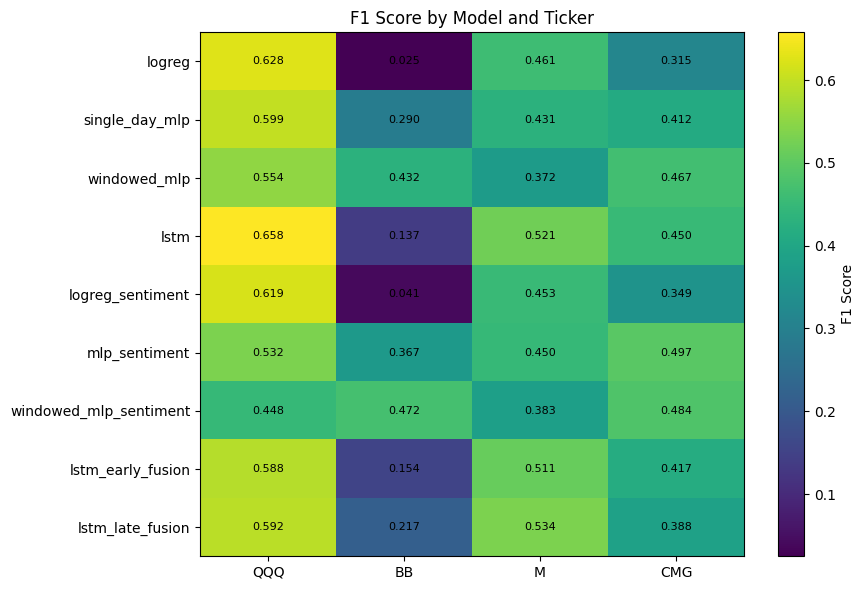

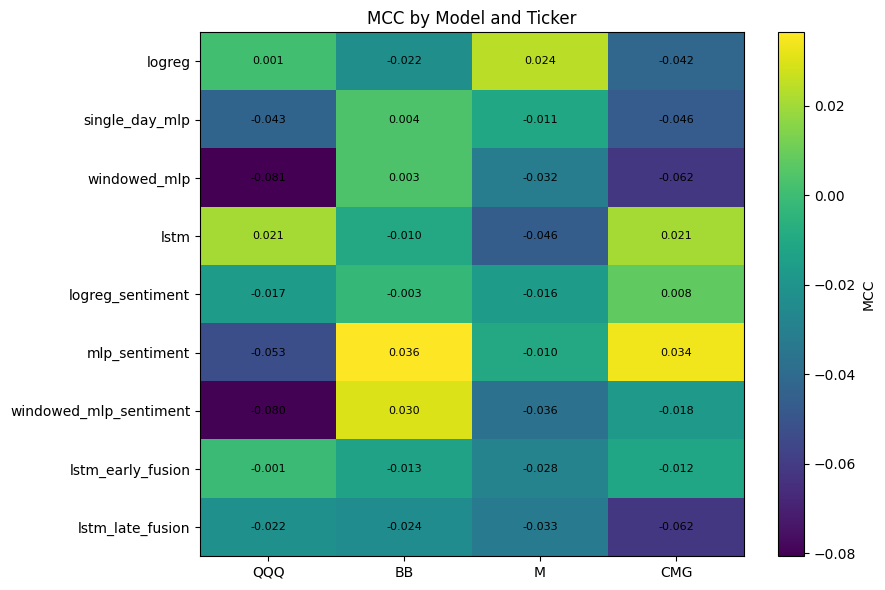

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

metrics_df = pd.DataFrame(all_metrics)
trading_df = pd.DataFrame(all_trading)

metrics_plot_df = (
    metrics_df.groupby(["model", "ticker"], as_index=False)
    .agg({
        "mean": "mean",
        "accuracy": "mean",
        "precision": "mean",
        "recall": "mean",
        "f1": "mean",
        "mcc": "mean"
    })
)

trading_plot_df = (
    trading_df.groupby(["model", "ticker"], as_index=False)
    .agg({
        "profit_model": "mean",
        "profit_buyhold": "mean",
        "profit_perfect": "mean",
        "sharpe_model": "mean",
        "sharpe_buyhold": "mean",
        "sharpe_perfect": "mean",
        "trades": "mean",
        "skipped": "mean"
    })
)

model_order = [
    "logreg",
    "single_day_mlp",
    "windowed_mlp",
    "lstm",
    "logreg_sentiment",
    "mlp_sentiment",
    "windowed_mlp_sentiment",
    "lstm_early_fusion",
    "lstm_late_fusion"
]

ticker_order = ["QQQ", "BB", "M", "CMG"]

heatmap_df = (
    metrics_plot_df.pivot(index="model", columns="ticker", values="f1")
    .reindex(index=model_order, columns=ticker_order)
)

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(heatmap_df.values, aspect="auto")

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns)
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

ax.set_title("F1 Score by Model and Ticker")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("F1 Score")

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        val = heatmap_df.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

metrics_df = pd.DataFrame(all_metrics)

metrics_plot_df = (
    metrics_df.groupby(["model", "ticker"], as_index=False)
    .agg({
        "mean": "mean",
        "accuracy": "mean",
        "precision": "mean",
        "recall": "mean",
        "f1": "mean",
        "mcc": "mean"
    })
)

model_order = [
    "logreg",
    "single_day_mlp",
    "windowed_mlp",
    "lstm",
    "logreg_sentiment",
    "mlp_sentiment",
    "windowed_mlp_sentiment",
    "lstm_early_fusion",
    "lstm_late_fusion"
]

ticker_order = ["QQQ", "BB", "M", "CMG"]

heatmap_df = (
    metrics_plot_df.pivot(index="model", columns="ticker", values="mcc")
    .reindex(index=model_order, columns=ticker_order)
)

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(heatmap_df.values, aspect="auto")

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns)
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

ax.set_title("MCC by Model and Ticker")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("MCC")

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        val = heatmap_df.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

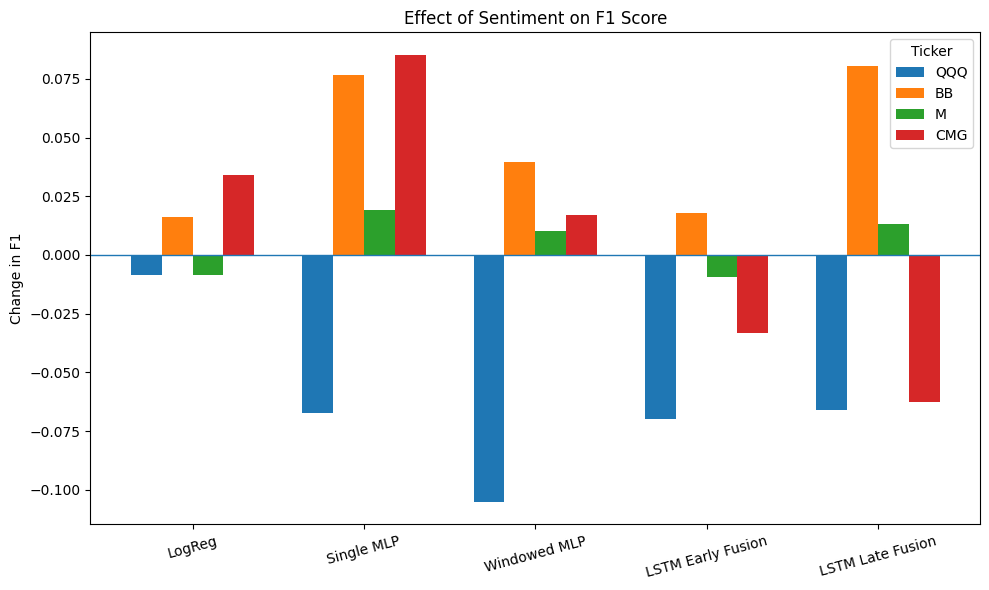

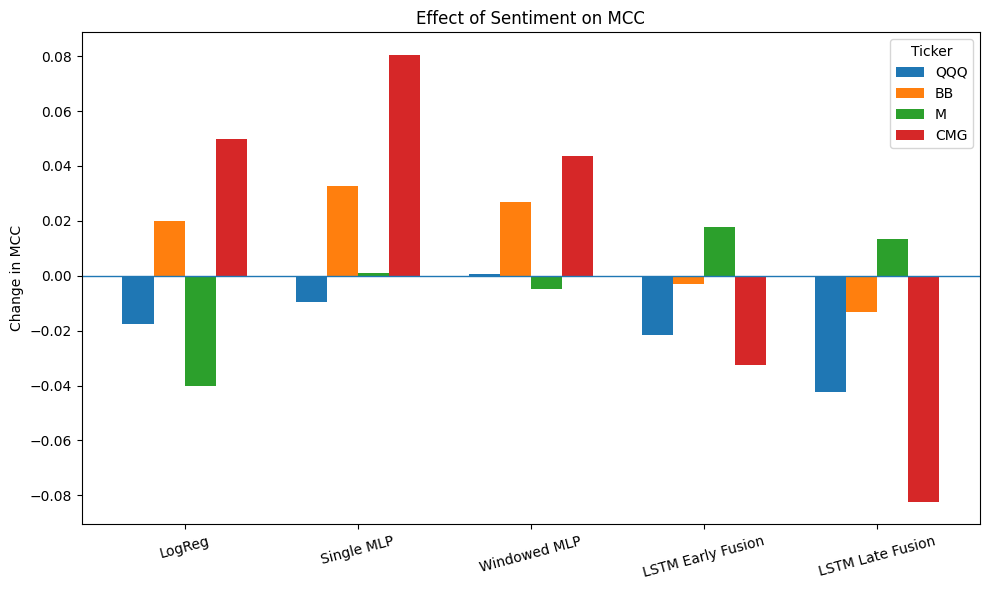

In [40]:
sentiment_pairs = [
    ("logreg", "logreg_sentiment", "LogReg"),
    ("single_day_mlp", "mlp_sentiment", "Single MLP"),
    ("windowed_mlp", "windowed_mlp_sentiment", "Windowed MLP"),
    ("lstm", "lstm_early_fusion", "LSTM Early Fusion"),
    ("lstm", "lstm_late_fusion", "LSTM Late Fusion")
]

delta_rows = []

for base_model, sent_model, label in sentiment_pairs:
    base = metrics_plot_df[metrics_plot_df["model"] == base_model][["ticker", "f1"]].rename(columns={"f1": "base_f1"})
    sent = metrics_plot_df[metrics_plot_df["model"] == sent_model][["ticker", "f1"]].rename(columns={"f1": "sent_f1"})

    merged = base.merge(sent, on="ticker", how="inner")
    merged["comparison"] = label
    merged["delta_f1"] = merged["sent_f1"] - merged["base_f1"]

    delta_rows.append(merged[["comparison", "ticker", "delta_f1"]])

delta_df = pd.concat(delta_rows, ignore_index=True)

comparisons = list(delta_df["comparison"].unique())
tickers = ["QQQ", "BB", "M", "CMG"]
x = np.arange(len(comparisons))
width = 0.18

fig, ax = plt.subplots(figsize=(10, 6))

for i, ticker in enumerate(tickers):
    vals = (
        delta_df[delta_df["ticker"] == ticker]
        .set_index("comparison")
        .reindex(comparisons)["delta_f1"]
        .values
    )
    ax.bar(x + (i - 1.5) * width, vals, width=width, label=ticker)

ax.axhline(0, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(comparisons, rotation=15)
ax.set_ylabel("Change in F1")
ax.set_title("Effect of Sentiment on F1 Score")
ax.legend(title="Ticker")

plt.tight_layout()
plt.show()


sentiment_pairs = [
    ("logreg", "logreg_sentiment", "LogReg"),
    ("single_day_mlp", "mlp_sentiment", "Single MLP"),
    ("windowed_mlp", "windowed_mlp_sentiment", "Windowed MLP"),
    ("lstm", "lstm_early_fusion", "LSTM Early Fusion"),
    ("lstm", "lstm_late_fusion", "LSTM Late Fusion")
]

delta_rows = []

for base_model, sent_model, label in sentiment_pairs:
    base = metrics_plot_df[metrics_plot_df["model"] == base_model][["ticker", "mcc"]].rename(columns={"mcc": "base_mcc"})
    sent = metrics_plot_df[metrics_plot_df["model"] == sent_model][["ticker", "mcc"]].rename(columns={"mcc": "sent_mcc"})

    merged = base.merge(sent, on="ticker", how="inner")
    merged["comparison"] = label
    merged["delta_mcc"] = merged["sent_mcc"] - merged["base_mcc"]

    delta_rows.append(merged[["comparison", "ticker", "delta_mcc"]])

delta_df = pd.concat(delta_rows, ignore_index=True)

comparisons = list(delta_df["comparison"].unique())
tickers = ["QQQ", "BB", "M", "CMG"]
x = np.arange(len(comparisons))
width = 0.18

fig, ax = plt.subplots(figsize=(10, 6))

for i, ticker in enumerate(tickers):
    vals = (
        delta_df[delta_df["ticker"] == ticker]
        .set_index("comparison")
        .reindex(comparisons)["delta_mcc"]
        .values
    )
    ax.bar(x + (i - 1.5) * width, vals, width=width, label=ticker)

ax.axhline(0, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(comparisons, rotation=15)
ax.set_ylabel("Change in MCC")
ax.set_title("Effect of Sentiment on MCC")
ax.legend(title="Ticker")

plt.tight_layout()
plt.show()



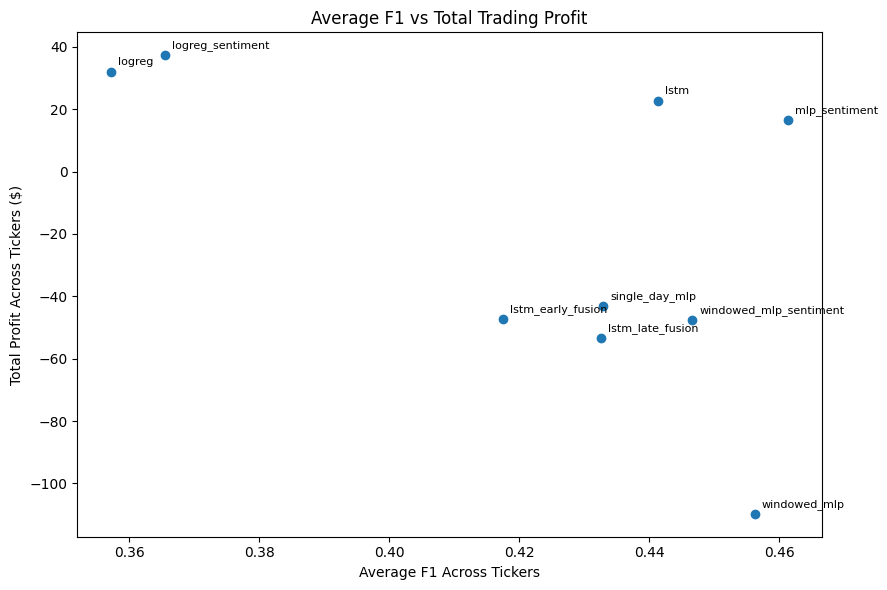

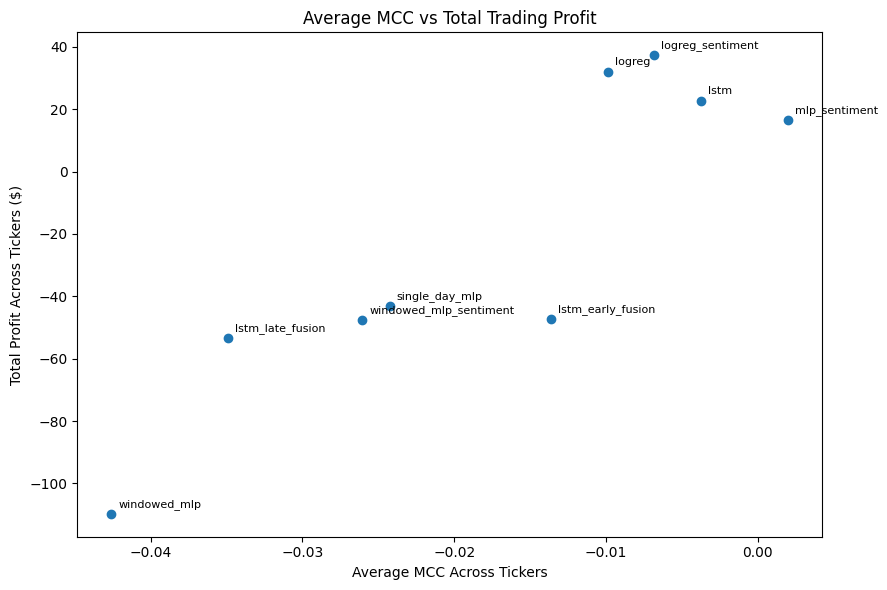

In [42]:
summary_df = (
    metrics_plot_df.groupby("model", as_index=False)["f1"].mean()
    .rename(columns={"f1": "avg_f1"})
    .merge(
        trading_plot_df.groupby("model", as_index=False)["profit_model"].sum(),
        on="model",
        how="inner"
    )
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(summary_df["avg_f1"], summary_df["profit_model"])

for _, row in summary_df.iterrows():
    ax.annotate(
        row["model"],
        (row["avg_f1"], row["profit_model"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_xlabel("Average F1 Across Tickers")
ax.set_ylabel("Total Profit Across Tickers ($)")
ax.set_title("Average F1 vs Total Trading Profit")

plt.tight_layout()
plt.show()

summary_df = (
    metrics_plot_df.groupby("model", as_index=False)["mcc"].mean()
    .rename(columns={"mcc": "avg_mcc"})
    .merge(
        trading_plot_df.groupby("model", as_index=False)["profit_model"].sum(),
        on="model",
        how="inner"
    )
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(summary_df["avg_mcc"], summary_df["profit_model"])

for _, row in summary_df.iterrows():
    ax.annotate(
        row["model"],
        (row["avg_mcc"], row["profit_model"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_xlabel("Average MCC Across Tickers")
ax.set_ylabel("Total Profit Across Tickers ($)")
ax.set_title("Average MCC vs Total Trading Profit")

plt.tight_layout()
plt.show()

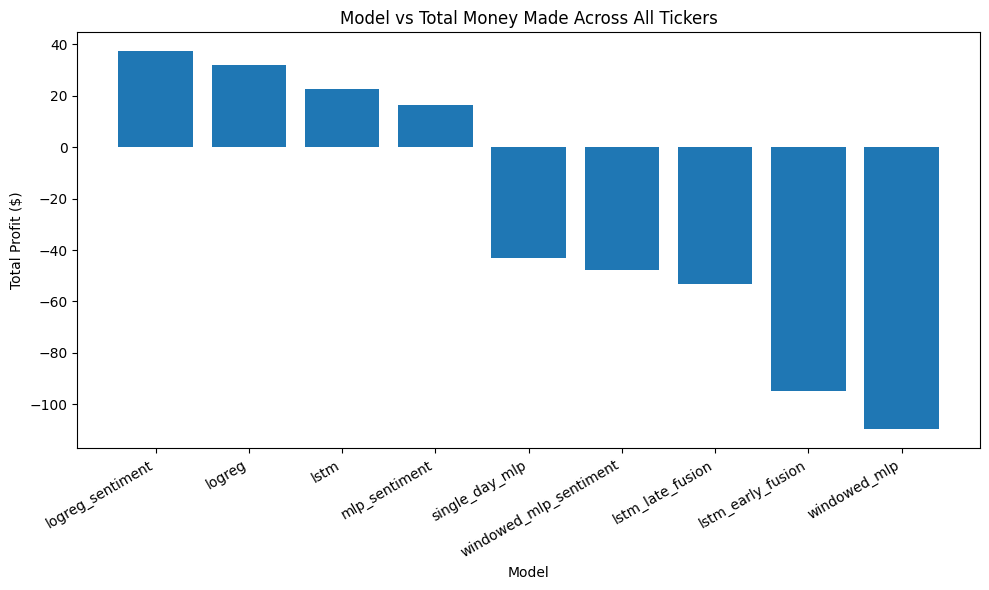

In [44]:
# Total profit by model across all tickers

import pandas as pd
import matplotlib.pyplot as plt

trading_df = pd.DataFrame(all_trading)

profit_by_model = (
    trading_df.groupby("model", as_index=False)["profit_model"]
    .sum()
    .sort_values("profit_model", ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(profit_by_model["model"], profit_by_model["profit_model"])
plt.xlabel("Model")
plt.ylabel("Total Profit ($)")
plt.title("Model vs Total Money Made Across All Tickers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()